## 01 - Разведочный анализ данных (EDA)

**Задача:** Классификация музыкального жанра по аудио-характеристикам и текстовым признакам  
**Датасет:** Music Dataset: 1950 to 2019  
**Целевая переменная:** `genre`

В этом ноутбуке:
1. Загружаем и изучаем датасет
2. Анализируем целевую переменную и обосновываем выбор метрики
3. Находим пропуски и дубликаты
4. Чистим данные
5. Анализируем выбросы и распределения признаков
6. Проводим корреляционный анализ
7. Извлекаем текстовые признаки из lyrics
8. Делаем раздеение данных на train/val/test

## 0. Импорты и настройка

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, "../src")
from preprocessing import (
    AUDIO_FEATURES,
    META_FEATURES,
    TEXT_FEATURES,
    TOPIC_FEATURES,
    clean_data,
    extract_text_features,
    load_data,
    split_data,
)

warnings.filterwarnings("ignore")

# Фиксируем рандом для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (12, 5)

# Создаём папку для изображений заранее
os.makedirs("../report/images", exist_ok=True)

print("Зависимости загружены")

Зависимости загружены


## 1. Загрузка и обзор данных

In [2]:
df = load_data("../data/raw/tcc_ceds_music.csv")

print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nСтолбцы:\n{list(df.columns)}")

Загружено строк: 28372, столбцов: 30

Размер датасета: 28372 строк, 30 столбцов

Столбцы:
['artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'like/girls', 'sadness', 'feelings', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy', 'topic', 'age']


In [3]:
# Типы данных и первые строки
print("Типы данных:")
print(df.dtypes)
df.head(3)

Типы данных:
artist_name                     str
track_name                      str
release_date                  int64
genre                           str
lyrics                          str
len                           int64
dating                      float64
violence                    float64
world/life                  float64
night/time                  float64
shake the audience          float64
family/gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement/places             float64
light/visual perceptions    float64
family/spiritual            float64
like/girls                  float64
sadness                     float64
feelings                    float64
danceability                float64
loudness                    float64
acousticness                float64
instrumentalness            float64
valence                     float64
energy         

,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,night/time,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0


In [4]:
# Описательная статистика для числовых столбцов
df.describe().round(3)

,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,...,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,age
count,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,...,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000,28372.000
mean,1990.237,73.028,0.021,0.118,0.121,0.057,0.017,0.017,0.049,0.077,...,0.028,0.129,0.031,0.533,0.665,0.339,0.080,0.533,0.570,0.425
std,18.487,41.830,0.052,0.179,0.172,0.112,0.041,0.042,0.106,0.110,...,0.058,0.181,0.072,0.173,0.108,0.327,0.211,0.251,0.244,0.264
min,1950.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.005,0.000,0.000,0.000,0.000,0.000,0.014
25%,1975.000,42.000,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.001,0.001,0.001,0.413,0.595,0.034,0.000,0.329,0.380,0.186
50%,1991.000,63.000,0.001,0.003,0.007,0.002,0.002,0.002,0.002,0.003,...,0.002,0.005,0.002,0.539,0.679,0.226,0.000,0.539,0.581,0.414
75%,2007.000,93.000,0.004,0.193,0.198,0.066,0.010,0.005,0.042,0.132,...,0.027,0.235,0.033,0.657,0.749,0.633,0.009,0.738,0.773,0.643
max,2019.000,199.000,0.648,0.982,0.962,0.974,0.497,0.545,0.941,0.646,...,0.594,0.981,0.959,0.994,1.000,1.000,0.997,1.000,1.000,1.000


## 2. Анализ целевой переменной — `genre`

In [5]:
genre_counts = df["genre"].value_counts()
print("Распределение жанров:")
print(genre_counts)
print(f"\nВсего жанров: {df['genre'].nunique()}")

Распределение жанров:
genre
pop        7042
country    5445
blues      4604
rock       4034
jazz       3845
reggae     2498
hip hop     904
Name: count, dtype: int64

Всего жанров: 7


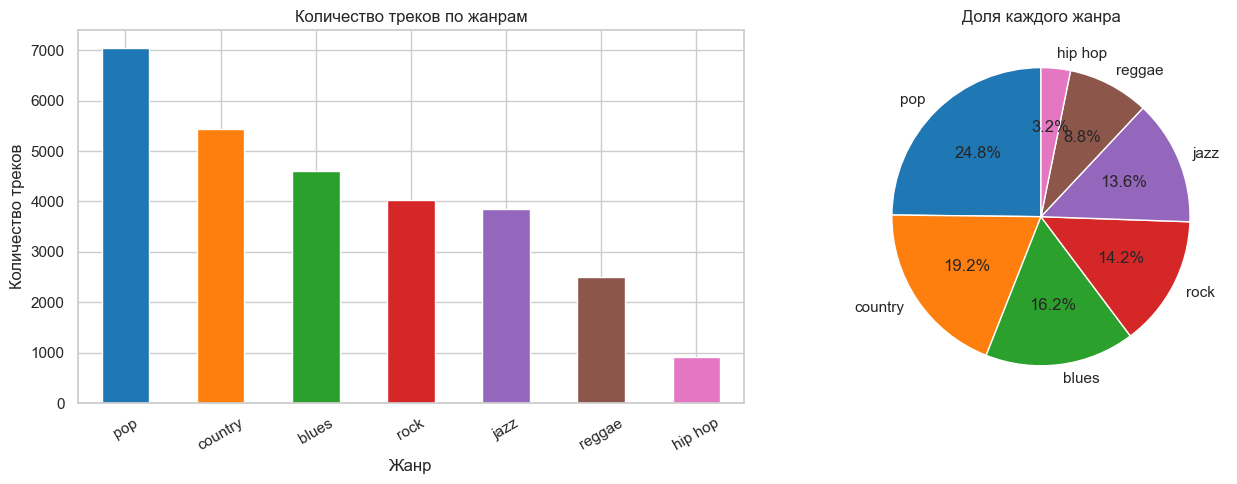


Коэффициент дисбаланса (max/min): 7.8


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
genre_counts.plot.bar(ax=axes[0], color=sns.color_palette("tab10", len(genre_counts)))
axes[0].set_title("Количество треков по жанрам")
axes[0].set_xlabel("Жанр")
axes[0].set_ylabel("Количество треков")
axes[0].tick_params(axis="x", rotation=30)

# Круговая диаграмма
axes[1].pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("tab10", len(genre_counts)),
    startangle=90,
)
axes[1].set_title("Доля каждого жанра")

plt.tight_layout()
plt.savefig("../report/images/genre_distribution.png", bbox_inches="tight")
plt.show()

# Дисбаланс
imbalance_ratio = genre_counts.max() / genre_counts.min()
print(f"\nКоэффициент дисбаланса (max/min): {imbalance_ratio:.1f}")

Вывод: классы несбалансированы - используем Macro F1 как основную метрику, чтобы модель не игнорировала редкие жанры

## 3. Пропущенные значения и дубликаты

In [7]:
# Пропущенные значения
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Количество": missing, "Процент, %": missing_pct})
missing_with_data = missing_df[missing_df["Количество"] > 0]

if len(missing_with_data) > 0:
    print("Столбцы с пропусками:")
    print(missing_with_data)

    fig, ax = plt.subplots(figsize=(10, 4))
    missing_with_data["Количество"].plot.bar(ax=ax, color="coral")
    ax.set_title("Количество пропущенных значений по столбцам")
    ax.set_ylabel("Количество пропусков")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("../report/images/missing_values.png", bbox_inches="tight")
    plt.show()
else:
    print("Пропущенных значений нет")

Пропущенных значений нет


In [8]:
# Дубликаты
n_full_dups = df.duplicated().sum()
n_track_dups = df.duplicated(subset=["artist_name", "track_name"]).sum()

print(f"Полных дубликатов строк: {n_full_dups}")
print(f"Дубликатов по (artist_name, track_name): {n_track_dups}")

Полных дубликатов строк: 0
Дубликатов по (artist_name, track_name): 0


## 4. Очистка данных

In [9]:
print(f"Размер до очистки: {df.shape}")
df_clean = clean_data(df)
print(f"Размер после очистки: {df_clean.shape}")

Размер до очистки: (28372, 30)
Переименованы столбцы: {'dating': 'dating', 'violence': 'violence', 'world/life': 'world_life', 'night/time': 'night_time', 'shake the audience': 'shake_the_audience', 'family/gospel': 'family_gospel', 'romantic': 'romantic', 'communication': 'communication', 'obscene': 'obscene', 'music': 'music', 'movement/places': 'movement_places', 'light/visual perceptions': 'light_visual_perceptions', 'family/spiritual': 'family_spiritual', 'like/girls': 'like_girls', 'sadness': 'sadness', 'feelings': 'feelings'}
Удалено дубликатов: 0 (осталось строк: 28372)
Размер после очистки: (28372, 30)


## 5. Анализ выбросов — аудио-признаки

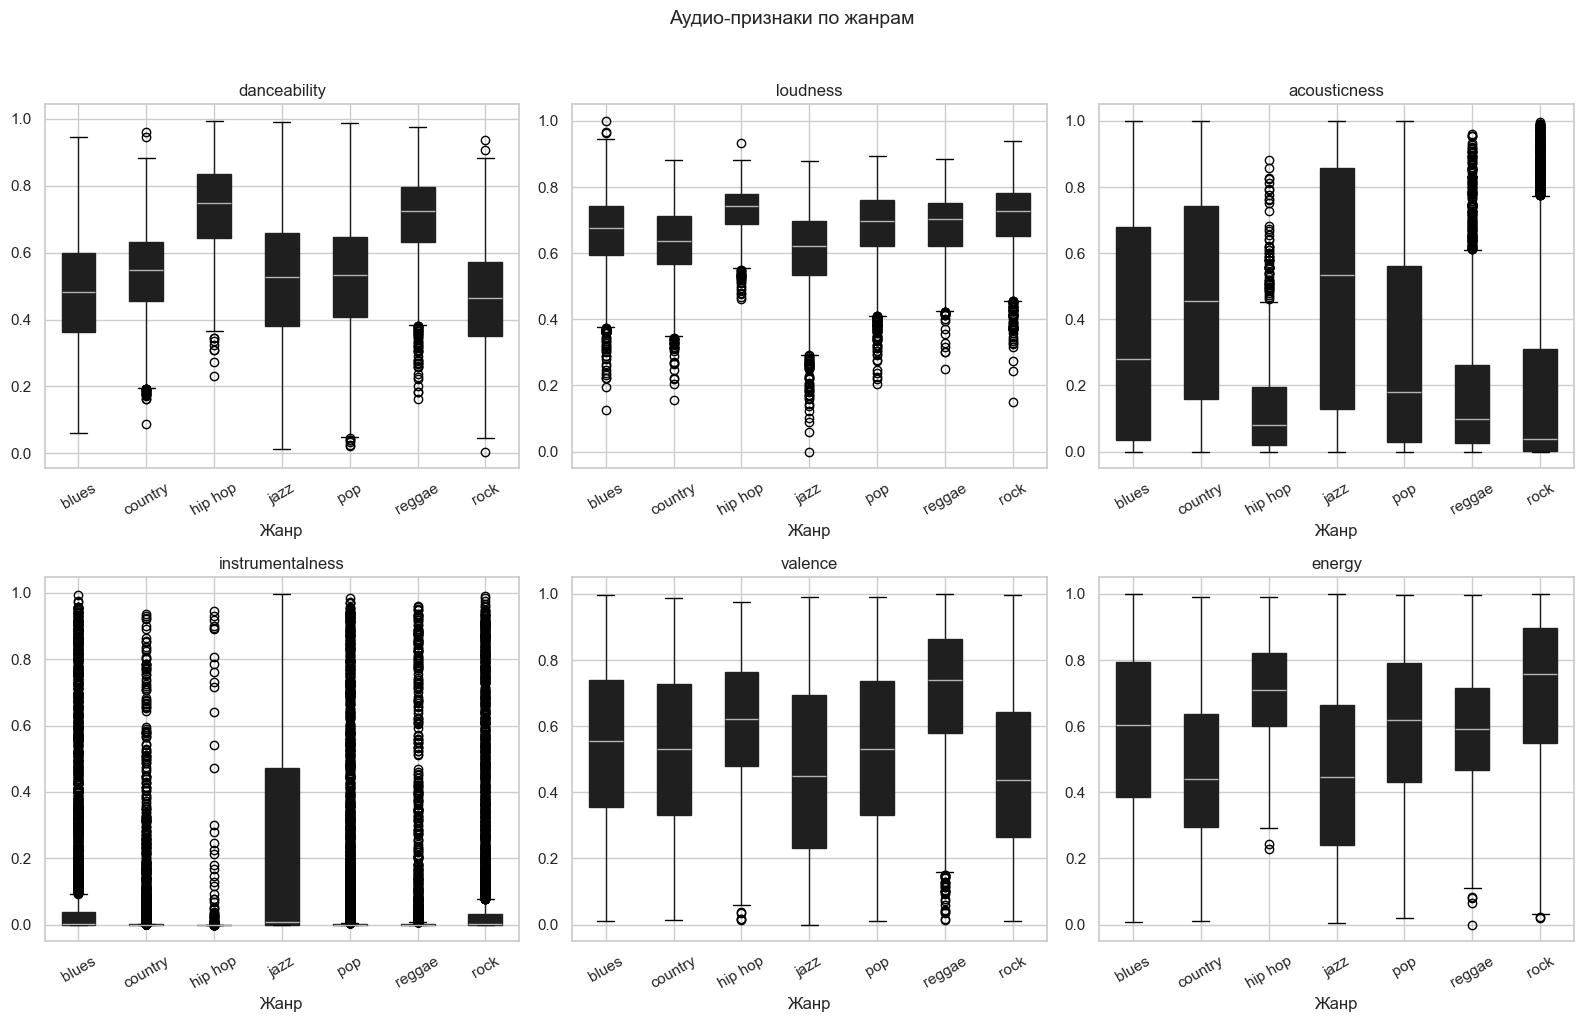

In [10]:
# Боксплоты аудио-признаков по жанрам
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(AUDIO_FEATURES):
    df_clean.boxplot(
        column=feature,
        by="genre",
        ax=axes[i],
        vert=True,
        patch_artist=True,
    )
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel("Жанр")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Аудио-признаки по жанрам", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../report/images/audio_boxplots_by_genre.png", bbox_inches="tight")
plt.show()

In [11]:
# IQR-анализ выбросов для каждого аудио-признака
print("IQR-анализ выбросов (аудио-признаки):")
outlier_summary = []

for feature in AUDIO_FEATURES:
    q1 = df_clean[feature].quantile(0.25)
    q3 = df_clean[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df_clean[feature] < lower) | (df_clean[feature] > upper)).sum()
    outlier_pct = n_outliers / len(df_clean) * 100
    outlier_summary.append(
        {
            "Признак": feature,
            "Q1": round(q1, 3),
            "Q3": round(q3, 3),
            "Нижняя граница IQR": round(lower, 3),
            "Верхняя граница IQR": round(upper, 3),
            "Выбросов": n_outliers,
            "Выбросов, %": round(outlier_pct, 2),
        }
    )

pd.DataFrame(outlier_summary)

IQR-анализ выбросов (аудио-признаки):


,Признак,Q1,Q3,Нижняя граница IQR,Верхняя граница IQR,Выбросов,"Выбросов, %"
0,danceability,0.413,0.657,0.047,1.022,11,0.04
1,loudness,0.595,0.749,0.365,0.980,274,0.97
2,acousticness,0.034,0.633,-0.863,1.530,0,0.00
3,instrumentalness,0.000,0.009,-0.014,0.023,5929,20.90
4,valence,0.329,0.738,-0.285,1.352,0,0.00
5,energy,0.380,0.773,-0.208,1.361,0,0.00


**Вывод по выбросам:** Все аудио-признаки в датасете находятся в диапазоне [0, 1]. Выбросы физически обоснованы:
- `instrumentalness` - много значений у 0.8–1.0: инструментальные треки (классика, джаз) дают высокое значение, вокальные - близкое к нулю. это нормальная особенность признака
- Остальные признаки имеют единичные выбросы у крайних значений диапазона

Все выбросы оставляем - они несут реальную информацию о жанре

## 6. Распределение признаков по жанрам

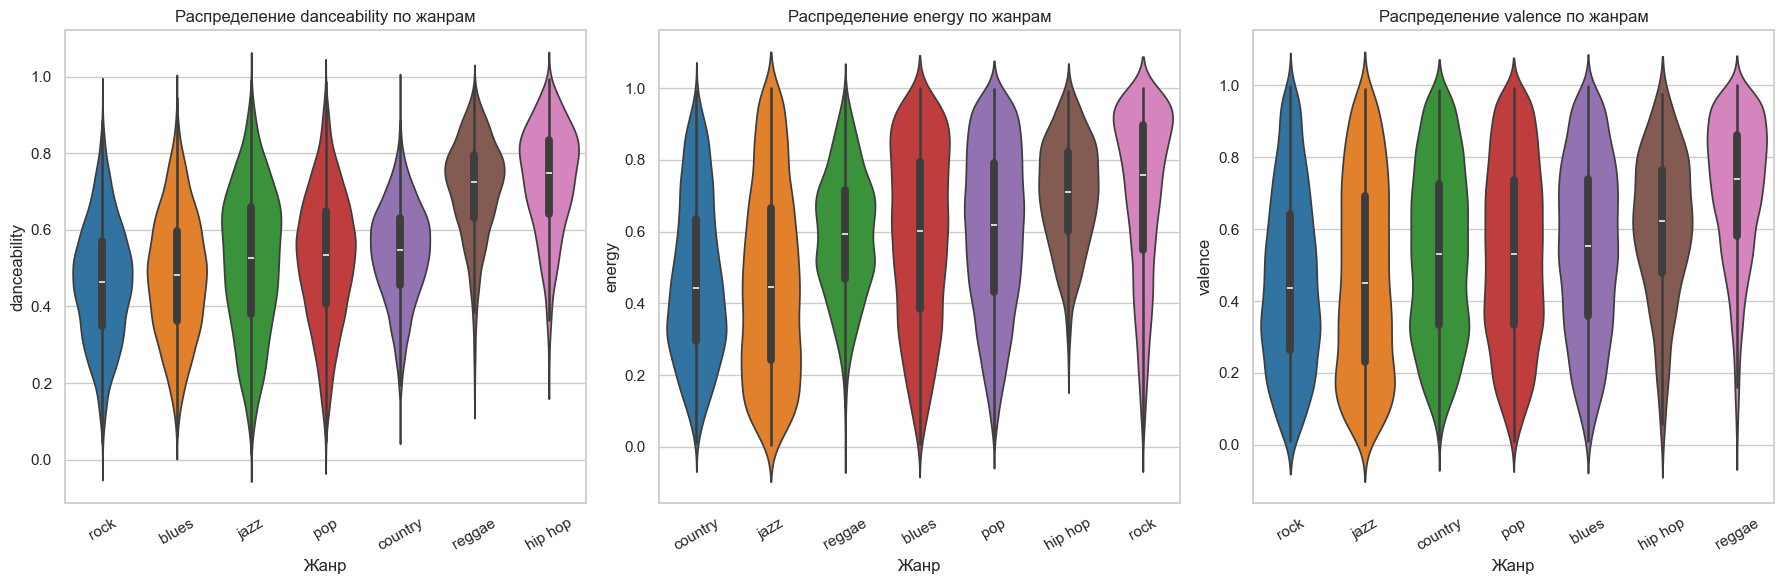

In [12]:
# Violin-plot для ключевых аудио-признаков
key_features = ["danceability", "energy", "valence"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feature in zip(axes, key_features):
    genres_sorted = df_clean.groupby("genre")[feature].median().sort_values().index
    sns.violinplot(
        data=df_clean,
        x="genre",
        y=feature,
        order=genres_sorted,
        ax=ax,
        palette="tab10",
    )
    ax.set_title(f"Распределение {feature} по жанрам")
    ax.set_xlabel("Жанр")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../report/images/violin_key_features.png", bbox_inches="tight")
plt.show()

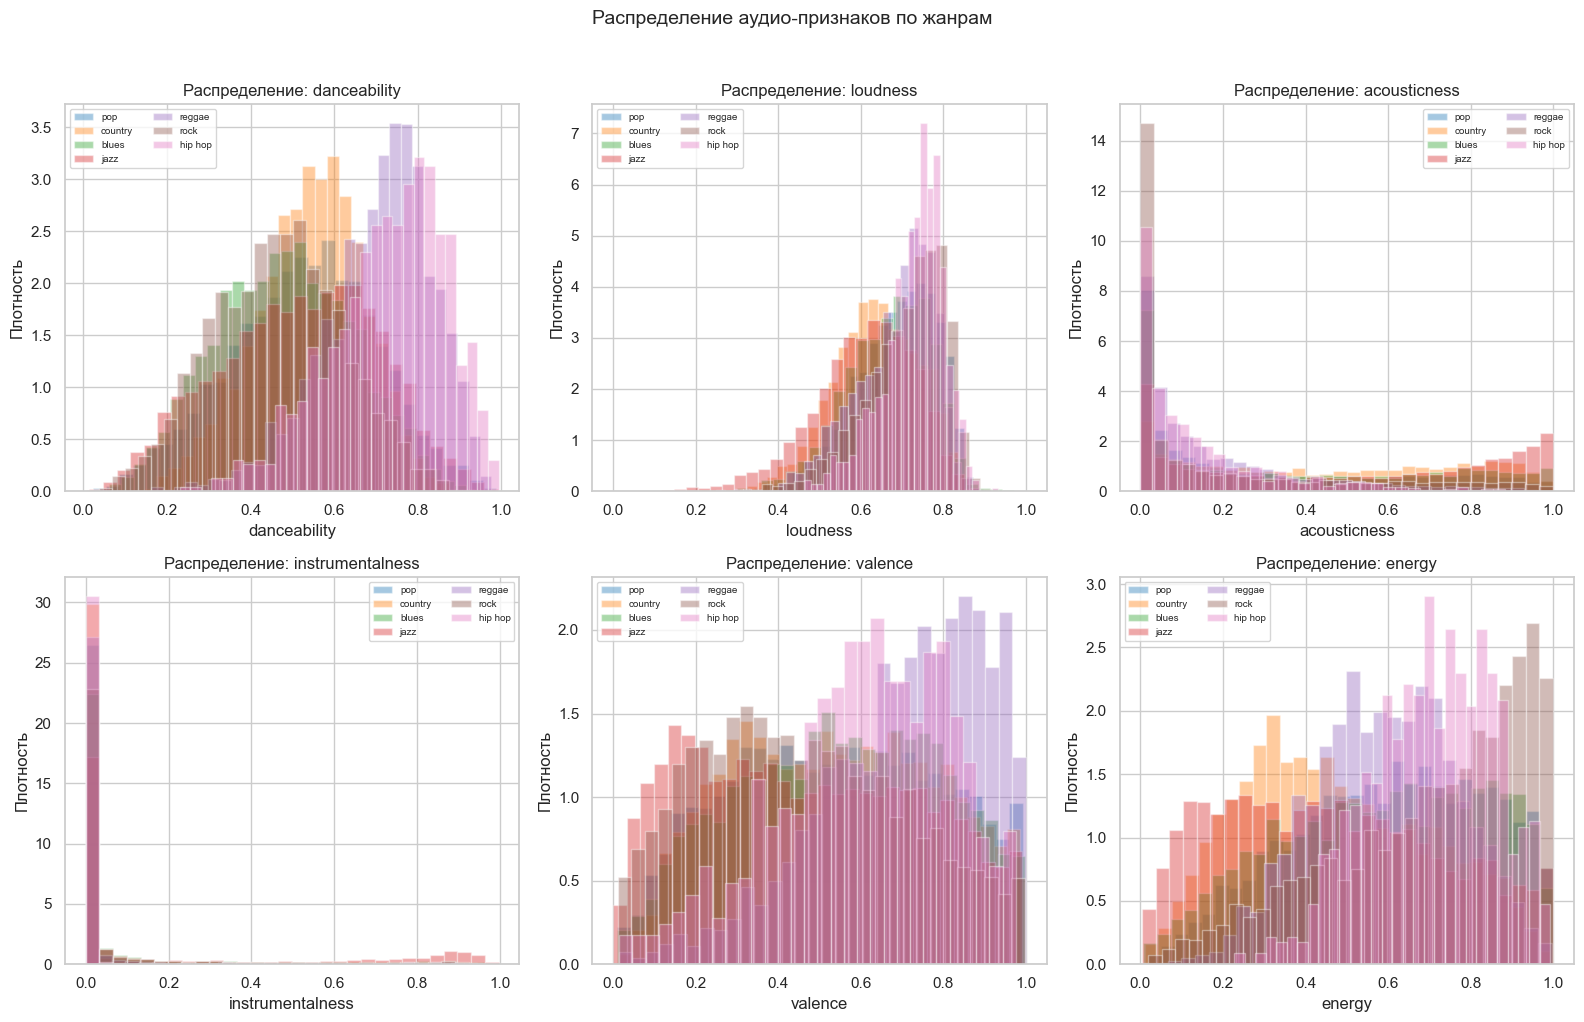

In [13]:
# Гистограммы всех аудио-признаков
genres = df_clean["genre"].unique()
colors = sns.color_palette("tab10", len(genres))
genre_color = dict(zip(genres, colors))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(AUDIO_FEATURES):
    for genre in genres:
        subset = df_clean[df_clean["genre"] == genre][feature].dropna()
        axes[i].hist(
            subset,
            bins=30,
            alpha=0.4,
            label=genre,
            color=genre_color[genre],
            density=True,
        )
    axes[i].set_title(f"Распределение: {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Плотность")
    axes[i].legend(fontsize=7, ncol=2)

plt.suptitle("Распределение аудио-признаков по жанрам", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../report/images/audio_histograms.png", bbox_inches="tight")
plt.show()

## 7. Временной анализ

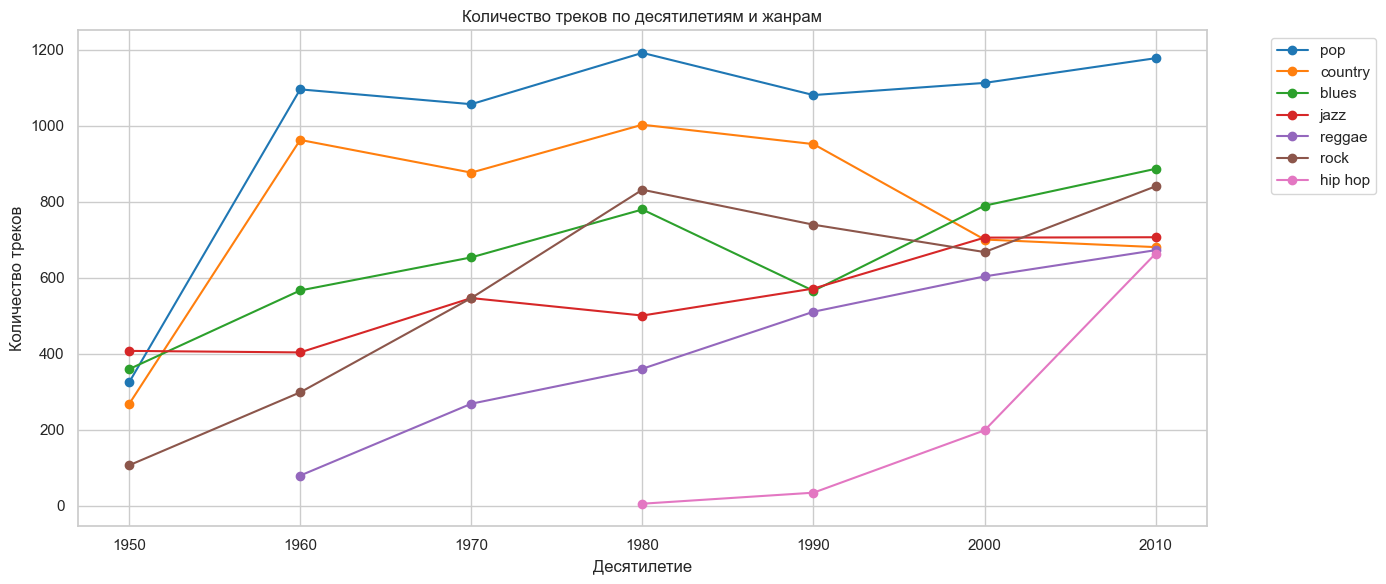

In [14]:
# Округляем год до десятилетий
df_clean["decade"] = (df_clean["release_date"] // 10 * 10).astype(int)

# Количество треков по жанрам и десятилетиям
decade_genre = df_clean.groupby(["decade", "genre"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(14, 6))
for genre in df_clean["genre"].unique():
    subset = decade_genre[decade_genre["genre"] == genre]
    ax.plot(subset["decade"], subset["count"], marker="o", label=genre)

ax.set_title("Количество треков по десятилетиям и жанрам")
ax.set_xlabel("Десятилетие")
ax.set_ylabel("Количество треков")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../report/images/tracks_by_decade.png", bbox_inches="tight")
plt.show()

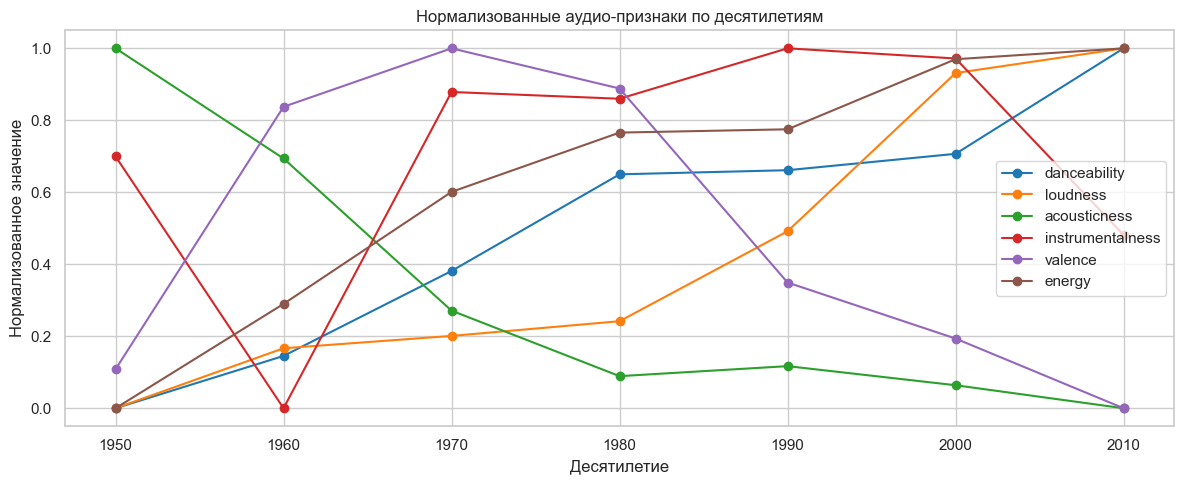

In [15]:
# Как менялись аудио-признаки со временем?
audio_by_decade = df_clean.groupby("decade")[AUDIO_FEATURES].mean()

fig, ax = plt.subplots(figsize=(12, 5))
for feature in AUDIO_FEATURES:
    normalized = (audio_by_decade[feature] - audio_by_decade[feature].min()) / (
        audio_by_decade[feature].max() - audio_by_decade[feature].min() + 1e-9
    )
    ax.plot(audio_by_decade.index, normalized, marker="o", label=feature)

ax.set_title("Нормализованные аудио-признаки по десятилетиям")
ax.set_xlabel("Десятилетие")
ax.set_ylabel("Нормализованное значение")
ax.legend()
plt.tight_layout()
plt.savefig("../report/images/audio_trends_by_decade.png", bbox_inches="tight")
plt.show()

## 8. Корреляционный анализ

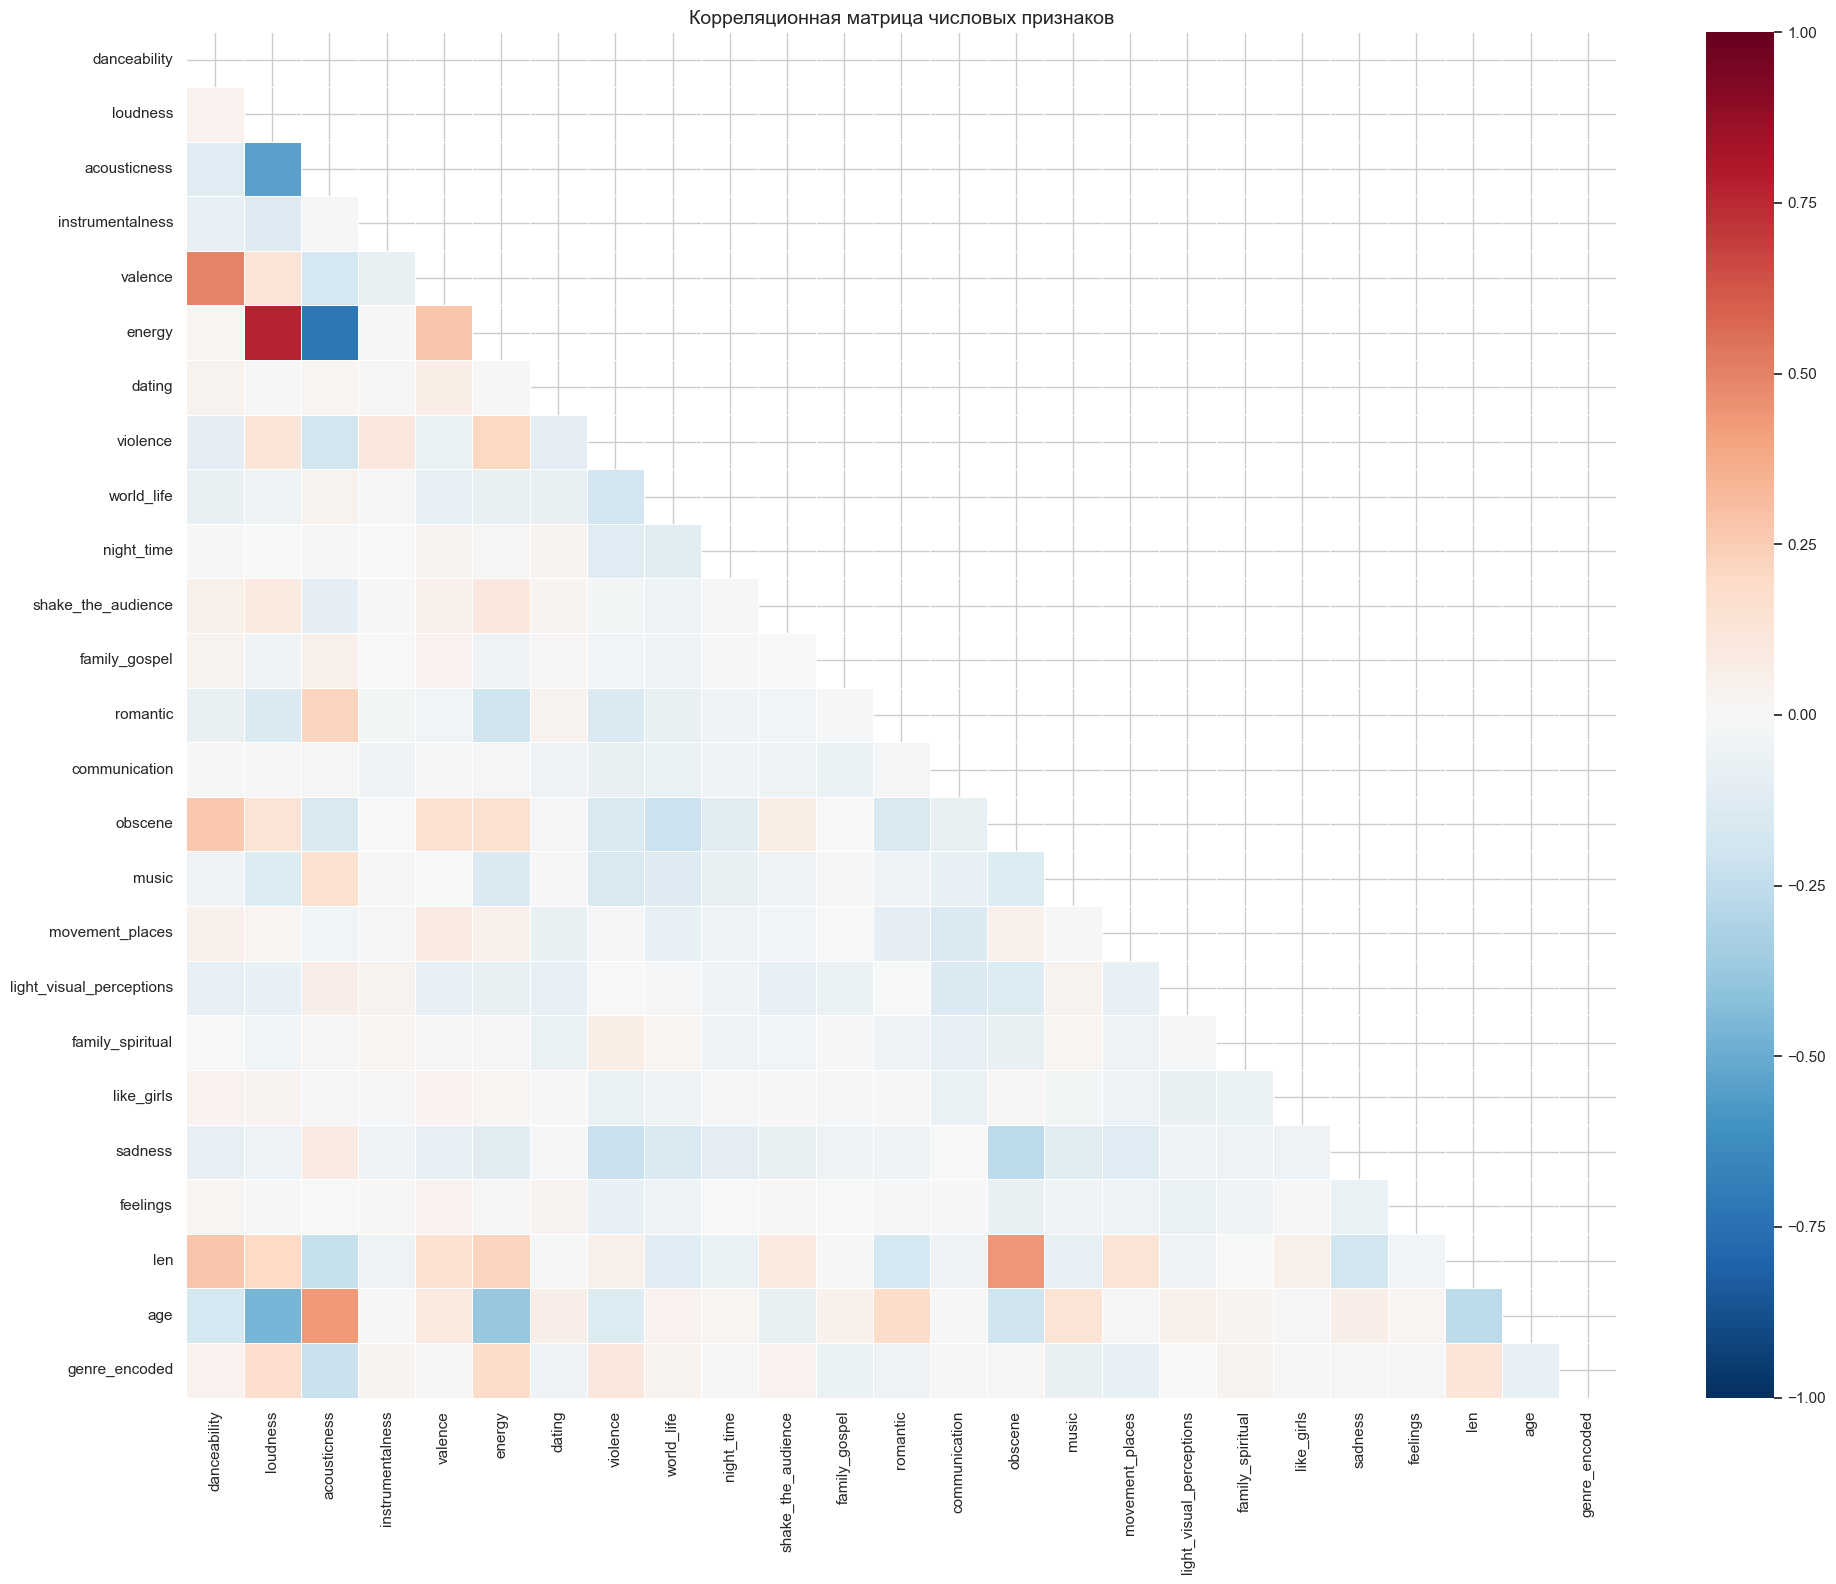

In [16]:
# Кодируем целевую переменную для корреляционного анализа
le = LabelEncoder()
df_clean["genre_encoded"] = le.fit_transform(df_clean["genre"])

# Тепловая карта корреляций числовых признаков
numeric_cols = AUDIO_FEATURES + TOPIC_FEATURES + META_FEATURES + ["genre_encoded"]
numeric_cols_present = [c for c in numeric_cols if c in df_clean.columns]

corr_matrix = df_clean[numeric_cols_present].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Корреляционная матрица числовых признаков", fontsize=14)
plt.tight_layout()
plt.savefig("../report/images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

Топ-10 признаков по корреляции с genre:
acousticness       0.224
energy             0.195
loudness           0.166
len                0.127
violence           0.105
age                0.088
movement_places    0.078
music              0.072
family_gospel      0.070
dating             0.061
Name: genre_encoded, dtype: float64


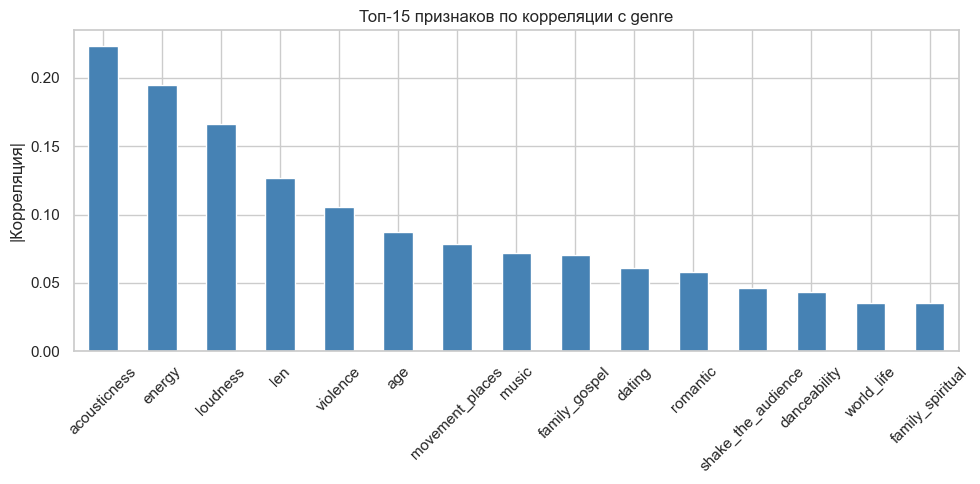

In [17]:
# Топ-10 признаков по корреляции с целевой переменной
target_corr = (
    corr_matrix["genre_encoded"]
    .drop("genre_encoded")
    .abs()
    .sort_values(ascending=False)
)

print("Топ-10 признаков по корреляции с genre:")
print(target_corr.head(10).round(3))

fig, ax = plt.subplots(figsize=(10, 5))
target_corr.head(15).plot.bar(ax=ax, color="steelblue")
ax.set_title("Топ-15 признаков по корреляции с genre")
ax.set_ylabel("|Корреляция|")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../report/images/feature_target_correlation.png", bbox_inches="tight")
plt.show()

## 9. Feature Engineering — текстовые признаки из lyrics

In [18]:
# Пример исходной строки lyrics
example_idx = df_clean[df_clean["lyrics"] != ""].index[0]
print("Пример lyrics (первые 200 символов):")
print(df_clean.loc[example_idx, "lyrics"][:200])
print(f"\nЖанр: {df_clean.loc[example_idx, 'genre']}")

Пример lyrics (первые 200 символов):
hold time feel break feel untrue convince speak voice tear try hold hurt try forgive okay play break string feel heart want feel tell real truth hurt lie worse anymore little turn dust play house ruin

Жанр: pop


In [19]:
# Извлекаем текстовые признаки
df_feat = extract_text_features(df_clean)
print("\nПример значений текстовых признаков:")
df_feat[["genre", "lyrics"] + TEXT_FEATURES].head(5)

Вычисляем текстовые признаки из lyrics...
Добавлены признаки: ['repetition_ratio', 'avg_word_length', 'sentiment_polarity']

Пример значений текстовых признаков:


,genre,lyrics,repetition_ratio,avg_word_length,sentiment_polarity
0,pop,hold time feel break feel untrue convince spea...,0.621053,4.505263,-0.096875
4,pop,believe drop rain fall grow believe darkest ni...,0.294118,5.215686,0.450000
6,pop,sweetheart send letter goodbye secret feel bet...,0.041667,5.416667,-0.110000
10,pop,kiss lips want stroll charm mambo chacha merin...,0.388889,4.833333,0.150000
12,pop,till darling till matter know till dream live ...,0.583333,4.708333,0.134091


In [20]:
# Статистика текстовых признаков по жанрам
print("Средние значения текстовых признаков по жанрам:")
df_feat.groupby("genre")[TEXT_FEATURES].mean().round(3)

Средние значения текстовых признаков по жанрам:


,repetition_ratio,avg_word_length,sentiment_polarity
genre,,,
blues,0.434,5.040,0.065
country,0.400,5.018,0.084
hip hop,0.282,5.259,0.019
jazz,0.391,5.245,0.078
pop,0.456,5.099,0.063
reggae,0.438,5.205,0.051
rock,0.411,5.153,0.045


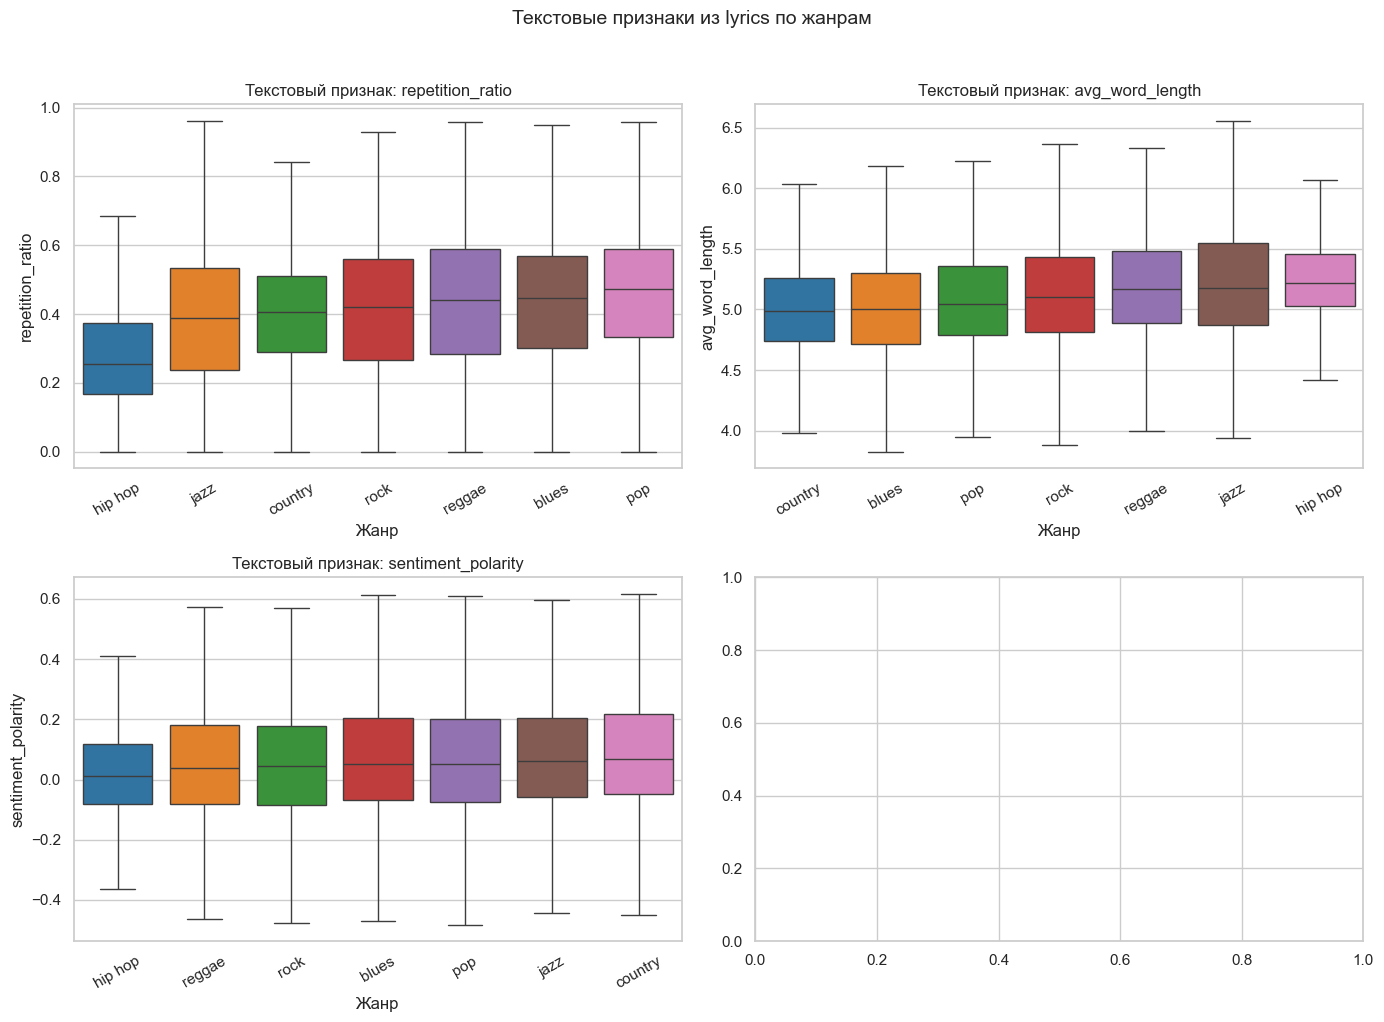

In [21]:
# Боксплоты текстовых признаков по жанрам
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(TEXT_FEATURES):
    genres_sorted = df_feat.groupby("genre")[feature].median().sort_values().index
    sns.boxplot(
        data=df_feat,
        x="genre",
        y=feature,
        order=genres_sorted,
        ax=axes[i],
        palette="tab10",
        showfliers=False,
    )
    axes[i].set_title(f"Текстовый признак: {feature}")
    axes[i].set_xlabel("Жанр")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Текстовые признаки из lyrics по жанрам", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../report/images/text_features_by_genre.png", bbox_inches="tight")
plt.show()

**Выводы по текстовым признакам:**

| Признак | Наблюдение | Полезность |
|---------|------------|------------|
| repetition_ratio | Hip-hop имеет **наименьшую** повторяемость (~0.25) — рэп-куплеты лексически разнообразны; pop/reggae выше (~0.45–0.5) | Умеренная |
| avg_word_length | Все жанры в диапазоне 4.5–5.5 символов, различия незначительные | Слабая |
| stretched_words_ratio | **Нулевой у всех жанров** — предобработка датасета нормализовала растянутые слова | Нет |
| sentiment_polarity | Hip-hop наиболее нейтральный/негативный (~0), country наиболее позитивный (~0.15) | Умеренная |

`stretched_words_ratio` удалён из набора признаков - константный признак не несёт информации и может зашумить модель.

Итого текстовых признаков: **3** (repetition_ratio, avg_word_length, sentiment_polarity)

## 10. Сплит Train / Val / Test

In [22]:
train_df, val_df, test_df = split_data(
    df_feat, test_size=0.15, val_size=0.15, random_state=RANDOM_STATE
)

Размеры выборок: train=19860, val=4256, test=4256 (всего: 28372)
Доли: train=70.0%, val=15.0%, test=15.0%


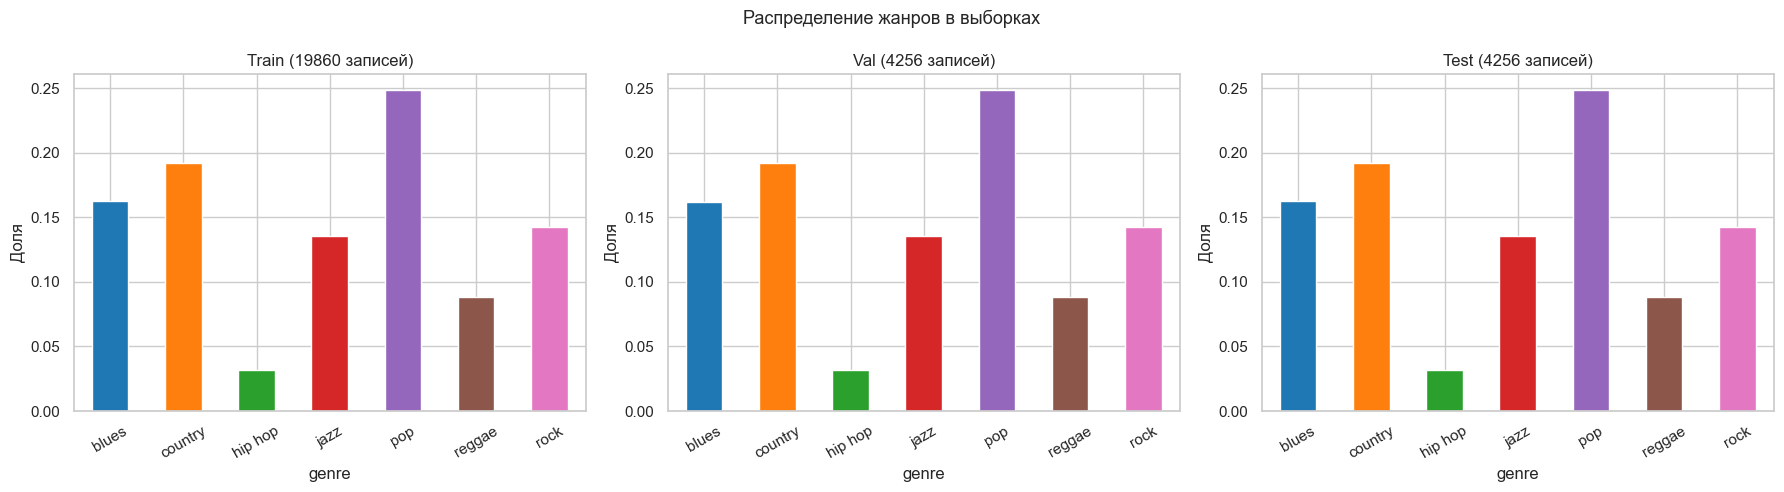


Доли жанров:


,Train,Val,Test
genre,,,
pop,0.248,0.248,0.248
country,0.192,0.192,0.192
blues,0.162,0.162,0.162
rock,0.142,0.142,0.142
jazz,0.135,0.136,0.136
reggae,0.088,0.088,0.088
hip hop,0.032,0.032,0.032


In [23]:
# Проверяем распределение жанров в каждом сплите
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]

for ax, (split_df, name) in zip(axes, splits):
    counts = split_df["genre"].value_counts(normalize=True).sort_index()
    counts.plot.bar(ax=ax, color=sns.color_palette("tab10", len(counts)))
    ax.set_title(f"{name} ({len(split_df)} записей)")
    ax.set_ylabel("Доля")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Распределение жанров в выборках", fontsize=13)
plt.tight_layout()
plt.savefig("../report/images/split_distribution.png", bbox_inches="tight")
plt.show()

print("\nДоли жанров:")
pd.concat(
    [
        split_df["genre"].value_counts(normalize=True).rename(name)
        for split_df, name in splits
    ],
    axis=1,
).round(3)

In [24]:
import os

os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Файлы сохранены в data/processed/:")
print(f"  train.csv  — {len(train_df)} строк")
print(f"  val.csv    — {len(val_df)} строк")
print(f"  test.csv   — {len(test_df)} строк")

Файлы сохранены в data/processed/:
  train.csv  — 19860 строк
  val.csv    — 4256 строк
  test.csv   — 4256 строк


## 11. Обоснование выбора метрики

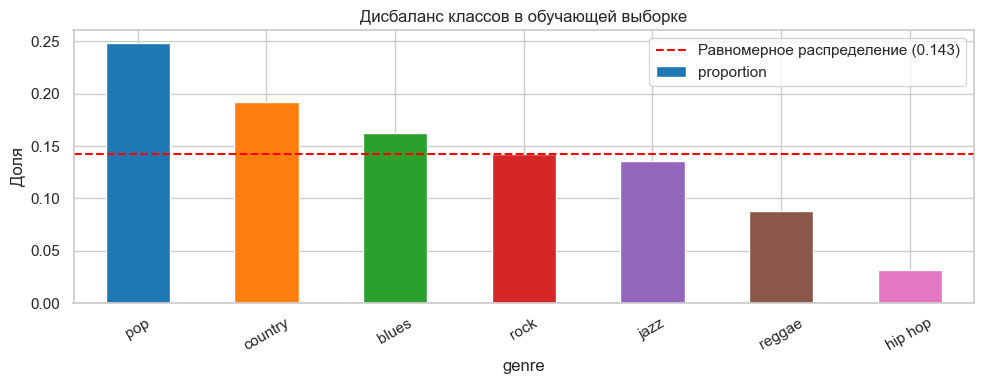

In [25]:
genre_train = (
    train_df["genre"].value_counts(normalize=True).sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
genre_train.plot.bar(ax=ax, color=sns.color_palette("tab10", len(genre_train)))
ax.axhline(
    1.0 / len(genre_train),
    color="red",
    linestyle="--",
    label=f"Равномерное распределение ({1 / len(genre_train):.3f})",
)
ax.set_title("Дисбаланс классов в обучающей выборке")
ax.set_ylabel("Доля")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../report/images/class_imbalance.png", bbox_inches="tight")
plt.show()

Обоснование выбора Macro F1:  
- Классы несбалансированы: крупнейший жанр больше наименьшего в 7.8 раз
- Macro F1 усредняет F1 по каждому жанру с равным весом, штрафуя за плохое качество на редких классах

Основная метрика: Macro F1
Дополнительная метрика: Accuracy

## Итоги EDA

| Что | Результат |
|--------|-----------|
| Размер датасета | ~28k треков, 1950–2019 |
| Количество жанров | 7 (pop, rock, hip hop, jazz, blues, country, reggae) |
| Дисбаланс классов | есть (pop ~1200 треков/десятилетие, hip hop появился в 1980-х) поэтому используем Macro F1 |
| Пропуски | не найдены |
| Дубликаты | не найдены |
| Выбросы | оставлены (физически обоснованы: instrumentalness - высокие значения у инструментальных треков) |
| Топ признаки по корреляции с genre | acousticness (0.22), energy (0.20), loudness (0.17), len (0.13) |
| Признаки | 6 аудио + 16 тематических + 3 текстовых + 2 мета = 27 |
| Исключён | stretched_words_ratio - нулевой у всех треков |
| Сплит | train/val/test = 70%/15%/15%, пропорции классов сохранены|